<a href="https://colab.research.google.com/github/barbaragodoy/analises-series-temporais-BMFBovespa/blob/main/N2_analise%3Dseries_temporais_BMFBovespa_Acoes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Checklist de Requisitos Acadêmicos

- [x] **R1 (Estatística):** Média, mediana, moda, variância, desvio padrão e interpretação textual concluídos.
- [x] **R2 (Visualização):** Scatter plot, Heatmap e Boxplot implementados com títulos e legendas.
- [x] **R3 (ML):** Regressão Linear e Random Forest implementados com métricas MAE, RMSE e R².

# Projeto de Análise de Séries Temporais - BMFBovespa (1986-2019)

## 1. Descrição da Base de Dados (R1)
Este dataset contém o histórico de cotações da bolsa de valores brasileira (B3/BMFBovespa) de 1986 a 2019.

### Explicação das Colunas Principais:
- **Trading Date**: Data do pregão.
- **Negociation Code**: Ticker da ação (ex: PETR4).
- **Preco_abertura**: Preço no início do pregão.
- **Preco_max / Preco_min**: Máxima e mínima do dia.
- **Preco_fechamento**: Último preço negociado.
- **Volume_acoes_negociadas**: Volume financeiro total no dia.

## 2. Tratamento de Dados e Limpeza

In [4]:
import pandas as pd
import kagglehub
import kagglehub

path = kagglehub.dataset_download("brunotly/bmfbovespas-time-series-19862019")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'bmfbovespas-time-series-19862019' dataset.
Path to dataset files: /kaggle/input/bmfbovespas-time-series-19862019


In [5]:
import numpy as np

# Recarregando com tratamento de tipos e otimização de memória
def load_and_clean_data(file_path):
    # Lendo apenas colunas necessárias para economizar RAM
    cols_to_use = [
        'Trading Date', 'Opening Price', 'Max. Price', 'Min. Price',
        'Mean Price', 'Last Trade Price', 'Numbor Of Trades',
        'Number Of Traded Stocks', 'Volume Of Traded Stocks'
    ]

    df = pd.read_csv(
        f"{file_path}/BMFBovespa_Cons_Dataset_1986-2019.csv",
        encoding='latin-1',
        usecols=cols_to_use,
        low_memory=False
    )

    # Renomeação Padronizada
    df.columns = [
        'Data', 'Preco_abertura', 'Preco_max', 'Preco_min',
        'Preco_med', 'Preco_fechamento', 'Num_transacoes',
        'Acoes_negociadas', 'Volume_total'
    ]

    # Tratamento de Datas
    df['Data'] = pd.to_datetime(df['Data'], format='%Y%m%d', errors='coerce')

    # Remoção de valores nulos e duplicados
    df = df.dropna().drop_duplicates()

    return df

precos_acoes = load_and_clean_data(path)
print(f"Dataset carregado: {precos_acoes.shape[0]} linhas pós-limpeza.")
display(precos_acoes.head())

Dataset carregado: 8080089 linhas pós-limpeza.


,Data,Preco_abertura,Preco_max,Preco_min,Preco_med,Preco_fechamento,Num_transacoes,Acoes_negociadas,Volume_total
0,1986-01-02,430.0,430.0,430.0,430.0,430.0,2.0,1200000.0,5.160000e+08
1,1986-01-02,2300.0,2500.0,2250.0,2356.0,2499.0,41.0,38176000.0,8.994291e+10
2,1986-01-02,150.0,150.0,150.0,150.0,150.0,3.0,12370000.0,1.855500e+09
3,1986-01-02,115100.0,115100.0,115100.0,115100.0,115100.0,1.0,4000.0,4.604000e+08
4,1986-01-02,1750.0,1850.0,1700.0,1779.0,1800.0,133.0,285075000.0,5.073268e+11


## 3. Estatística Descritiva com Interpretação Automática (R1)

In [6]:
def generate_summary_with_interpretation(df):
    stats = df.describe().T
    stats['median'] = df.median(numeric_only=True)
    stats['mode'] = df.mode(numeric_only=True).iloc[0]
    stats['variance'] = df.var(numeric_only=True)

    print("--- RESUMO ANALÍTICO ---\n")
    for col in ['Preco_fechamento', 'Volume_total']:
        avg = stats.loc[col, 'mean']
        med = stats.loc[col, 'median']
        std = stats.loc[col, 'std']

        print(f"Coluna: {col}")
        print(f"- Média: {avg:.2f} | Mediana: {med:.2f}")
        print(f"- Desvio Padrão: {std:.2f}")

        if std > avg:
            print("  Interpretação: Alta volatilidade detectada (Desvio padrão > Média).")
        else:
            print("  Interpretação: Dados relativamente estáveis em torno da média.")

        if avg > med:
            print("  Interpretação: Distribuição assimétrica à direita (outliers de valores altos).\n")
        else:
            print("  Interpretação: Distribuição equilibrada ou assimétrica à esquerda.\n")

generate_summary_with_interpretation(precos_acoes)

--- RESUMO ANALÍTICO ---

Coluna: Preco_fechamento
- Média: 82814.67 | Mediana: 759.00
- Desvio Padrão: 11968922.36
  Interpretação: Alta volatilidade detectada (Desvio padrão > Média).
  Interpretação: Distribuição assimétrica à direita (outliers de valores altos).

Coluna: Volume_total
- Média: 8870521304.11 | Mediana: 2360206.00
- Desvio Padrão: 1041682535562.24
  Interpretação: Alta volatilidade detectada (Desvio padrão > Média).
  Interpretação: Distribuição assimétrica à direita (outliers de valores altos).



In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
precos_acoes = pd.read_csv(f"{path}/BMFBovespa_Cons_Dataset_1986-2019.csv", encoding = 'latin-1')

/tmp/ipykernel_8424/1655366454.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  precos_acoes = pd.read_csv(f"{path}/BMFBovespa_Cons_Dataset_1986-2019.csv", encoding = 'latin-1')


In [9]:
import os
# List the contents of the downloaded dataset directory
print(os.listdir(path))

['BMFBovespa Layout.pdf', 'COTAHIST_A1995.txt', 'COTAHIST_A1987.txt', 'COTAHIST_A2016.txt', 'COTAHIST_A1994.txt', 'COTAHIST_A2005.txt', 'COTAHIST_A2002.txt', 'COTAHIST_A1988.txt', 'COTAHIST_A2017.txt', 'COTAHIST_A2009.txt', 'BMFBovespa_Cons_Dataset_1986-2019.csv', 'COTAHIST_A2019.txt', 'COTAHIST_A2007.txt', 'COTAHIST_A2012.txt', 'COTAHIST_A2018.txt', 'COTAHIST_A2010.txt', 'COTAHIST_A1991.txt', 'COTAHIST_A1989.txt', 'COTAHIST_A2001.txt', 'COTAHIST_A1992.txt', 'COTAHIST_A2008.txt', 'COTAHIST_A1998.txt', 'COTAHIST_A2011.txt', 'COTAHIST_A1996.txt', 'COTAHIST_A1999.txt', 'COTAHIST_A2014.txt', 'COTAHIST_A1986.txt', 'COTAHIST_A2000.txt', 'COTAHIST_A2004.txt', 'COTAHIST_A2015.txt', 'COTAHIST_A2006.txt', 'COTAHIST_A2003.txt', 'COTAHIST_A1997.txt', 'COTAHIST_A1993.txt', 'COTAHIST_A1990.txt', 'COTAHIST_A2013.txt']


In [10]:
precos_acoes

,Register Type,Trading Date,BDI Code,Negociation Code,Market Type,Trade Name,Specification,Forward Market Term In Days,Currency,Opening Price,...,Numbor Of Trades,Number Of Traded Stocks,Volume Of Traded Stocks,Price For Options Market Or Secondary Term Market,Price Corrections For Options Market Or Secondary Term Market,Due Date For Options Market Or Secondary Term Market,Factor Of Paper Quotatuion,Points In Price For Options Market Referenced In Dollar Or Secondary Term,ISIN Or Intern Code,Distribution Number
0,1,19860102,2.0,ACE 2,10,ACESITA,PP C03,NaN,CR$,430.0,...,2.0,1200000.0,5.160000e+08,0.0,0.0,99991231.0,1.0,0.0,ACESACPP,113.0
1,1,19860102,2.0,AVI 2,10,ACOS VILL,PP C37,NaN,CR$,2300.0,...,41.0,38176000.0,8.994291e+10,0.0,0.0,99991231.0,1.0,0.0,AVILACPP,135.0
2,1,19860102,2.0,CRA 2,10,ADUBOS CRA,PP C30,NaN,CR$,150.0,...,3.0,12370000.0,1.855500e+09,0.0,0.0,99991231.0,1.0,0.0,CRADACPP,119.0
3,1,19860102,2.0,AGR 11,10,AGRALE,PPB,NaN,CR$,115100.0,...,1.0,4000.0,4.604000e+08,0.0,0.0,99991231.0,1.0,0.0,AGRAACPPB,100.0
4,1,19860102,2.0,SAG 2,10,AGROCERES,PP C01,NaN,CR$,1750.0,...,133.0,285075000.0,5.073268e+11,0.0,0.0,99991231.0,1.0,0.0,SAGRACPP,21.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8125686,1,20191230,82.0,YDUQM47,80,YDUQE FM,ON NM,0.0,R$,152.0,...,5.0,10400.0,1.673200e+06,4700.0,0.0,20200120.0,1.0,0.0,BRYDUQACNOR3,100.0
8125687,1,20191230,82.0,YDUQM48,80,YDUQE FM,ON NM,0.0,R$,192.0,...,3.0,3200.0,6.699000e+05,4800.0,0.0,20200120.0,1.0,0.0,BRYDUQACNOR3,100.0
8125688,1,20191230,82.0,YDUQM49,80,YDUQE FM,ON NM,0.0,R$,258.0,...,4.0,10500.0,2.964000e+06,4900.0,0.0,20200120.0,1.0,0.0,BRYDUQACNOR3,100.0
8125689,1,20191230,82.0,YDUQN460,80,YDUQE,ON NM,0.0,R$,211.0,...,1.0,200.0,4.220000e+04,4600.0,0.0,20200217.0,1.0,0.0,BRYDUQACNOR3,100.0


In [11]:
#Filtrando e renomeando colunas de interesse
original_column_names = [
    'Opening Price',
    'Max. Price',
    'Min. Price',
    'Mean Price',
    'Last Trade Price',
    'Numbor Of Trades',
    'Number Of Traded Stocks',
    'Volume Of Traded Stocks'
]

df_estatistica = precos_acoes[original_column_names].copy() # Using .copy() to prevent SettingWithCopyWarning

new_column_names_map = {
    'Opening Price': 'Preco_abertura',
    'Max. Price': 'Preco_max',
    'Min. Price': 'Preco_min',
    'Mean Price': 'Preco_med',
    'Last Trade Price': 'Preco_fechamento',
    'Numbor Of Trades': 'Num_transacoes',
    'Number Of Traded Stocks': 'Acoes_negociadas',
    'Volume Of Traded Stocks': 'Volume_acoes_negociadas'
}

df_estatistica = df_estatistica.rename(columns=new_column_names_map)

print(df_estatistica.head())

   Preco_abertura  Preco_max  Preco_min  Preco_med  Preco_fechamento  \
0           430.0      430.0      430.0      430.0             430.0   
1          2300.0     2500.0     2250.0     2356.0            2499.0   
2           150.0      150.0      150.0      150.0             150.0   
3        115100.0   115100.0   115100.0   115100.0          115100.0   
4          1750.0     1850.0     1700.0     1779.0            1800.0   

   Num_transacoes  Acoes_negociadas  Volume_acoes_negociadas  
0             2.0         1200000.0             5.160000e+08  
1            41.0        38176000.0             8.994291e+10  
2             3.0        12370000.0             1.855500e+09  
3             1.0            4000.0             4.604000e+08  
4           133.0       285075000.0             5.073268e+11  


In [12]:
# Imprimir todos os nomes das colunas para identificar os nomes corretos
print(precos_acoes.columns)

Index(['Register Type', 'Trading Date', 'BDI Code', 'Negociation Code',
       'Market Type', 'Trade Name', 'Specification',
       'Forward Market Term In Days', 'Currency', 'Opening Price',
       'Max. Price', 'Min. Price', 'Mean Price', 'Last Trade Price',
       'Best Purshase Order Price', 'Best Purshase Sale Price',
       'Numbor Of Trades', 'Number Of Traded Stocks',
       'Volume Of Traded Stocks',
       'Price For Options Market Or Secondary Term Market',
       'Price Corrections For Options Market Or Secondary Term Market',
       'Due Date For Options Market Or Secondary Term Market',
       'Factor Of Paper Quotatuion',
       'Points In Price For Options Market Referenced In Dollar Or Secondary Term',
       'ISIN Or Intern Code ', 'Distribution Number'],
      dtype='object')


In [13]:
#media por colunas de interesse
df_estatistica.mean()

,0
Preco_abertura,8.282757e+04
Preco_max,8.445543e+04
Preco_min,8.198253e+04
Preco_med,8.346179e+04
Preco_fechamento,8.350531e+04
Num_transacoes,3.238522e+02
Acoes_negociadas,2.811770e+07
Volume_acoes_negociadas,8.823368e+09


In [14]:
#Mediana - números centrais
df_estatistica.median()

,0
Preco_abertura,750.0
Preco_max,760.0
Preco_min,734.0
Preco_med,747.0
Preco_fechamento,750.0
Num_transacoes,5.0
Acoes_negociadas,11143.0
Volume_acoes_negociadas,2308953.0


In [15]:
#moda - numero mais frequente nas amostras
df_estatistica.mode()

,Preco_abertura,Preco_max,Preco_min,Preco_med,Preco_fechamento,Num_transacoes,Acoes_negociadas,Volume_acoes_negociadas
0,1.0,1.0,1.0,1.0,1.0,1.0,100.0,10000.0


In [16]:
#Desvio padrão - Grau de dispersão em relação a média
df_estatistica.std()

,0
Preco_abertura,1.205495e+07
Preco_max,1.207393e+07
Preco_min,1.204911e+07
Preco_med,1.207271e+07
Preco_fechamento,1.206714e+07
Num_transacoes,2.037151e+03
Acoes_negociadas,7.202123e+08
Volume_acoes_negociadas,1.038758e+12


In [17]:
#Variância - Indica quão distantes os valores de um conjunto de dados estão da média
df_estatistica.var()

,0
Preco_abertura,1.453218e+14
Preco_max,1.457798e+14
Preco_min,1.451810e+14
Preco_med,1.457503e+14
Preco_fechamento,1.456159e+14
Num_transacoes,4.149984e+06
Acoes_negociadas,5.187058e+17
Volume_acoes_negociadas,1.079017e+24


In [18]:
#Indica os valor por quartis
df_estatistica.quantile([0.25, 0.5, 0.75])

,Preco_abertura,Preco_max,Preco_min,Preco_med,Preco_fechamento,Num_transacoes,Acoes_negociadas,Volume_acoes_negociadas
0.25,110.0,118.0,105.0,110.0,111.0,2.0,1000.0,209600.0
0.50,750.0,760.0,734.0,747.0,750.0,5.0,11143.0,2308953.0
0.75,3242.0,3293.0,3200.0,3241.0,3248.0,25.0,223873.0,25641500.0


## 4. Dashboard e Visualização (R2)

Nesta seção, exploramos as relações visuais entre as variáveis e a tendência temporal das cotações.

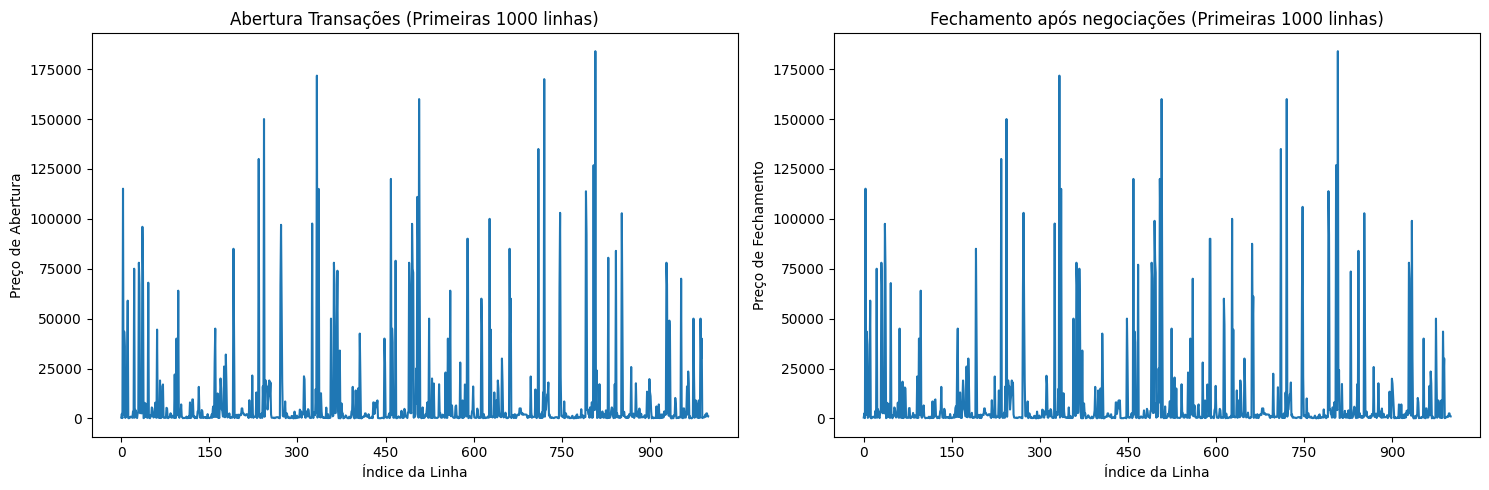

In [19]:
import matplotlib.pyplot as plt
from matplotlib import axes

# Plotting only the first 1000 rows for better visualization and performance
# For full dataset visualization, consider resampling or more advanced plotting techniques.
plot_data = df_estatistica.head(1000)

fig, axes = plt.subplots(1,2, figsize= (15,5))

axes[0].plot(plot_data.index, plot_data['Preco_abertura'])
axes[0].set_title('Abertura Transações (Primeiras 1000 linhas)')
axes[0].set_xlabel('Índice da Linha')
axes[0].set_ylabel('Preço de Abertura')
# Adjusted locator for fewer ticks on a smaller dataset
axes[0].xaxis.set_major_locator(plt.MaxNLocator(10))

axes[1].plot(plot_data.index, plot_data['Preco_fechamento'])
axes[1].set_title('Fechamento após negociações (Primeiras 1000 linhas)')
axes[1].set_xlabel('Índice da Linha')
axes[1].set_ylabel('Preço de Fechamento')
# Adjusted locator for fewer ticks on a smaller dataset
axes[1].xaxis.set_major_locator(plt.MaxNLocator(10))

plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

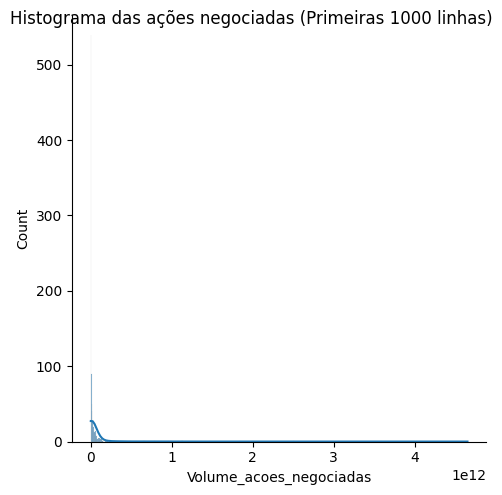

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# Using the first 1000 rows for the plot as previously intended
plot_data = df_estatistica.head(1000)

# Create the displot and store the FacetGrid object
g = sns.displot(plot_data["Volume_acoes_negociadas"], kde=True)

# Set the title on the FacetGrid object
g.fig.suptitle("Histograma das ações negociadas (Primeiras 1000 linhas)")

plt.show()

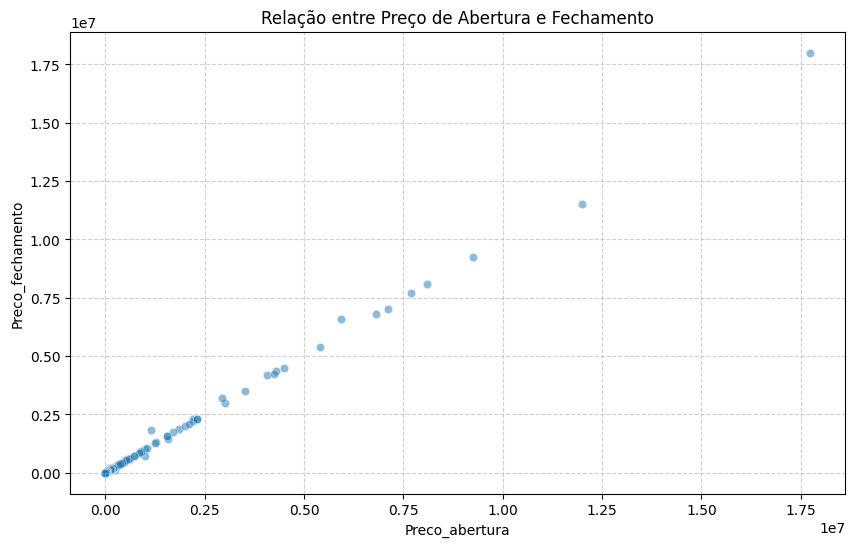

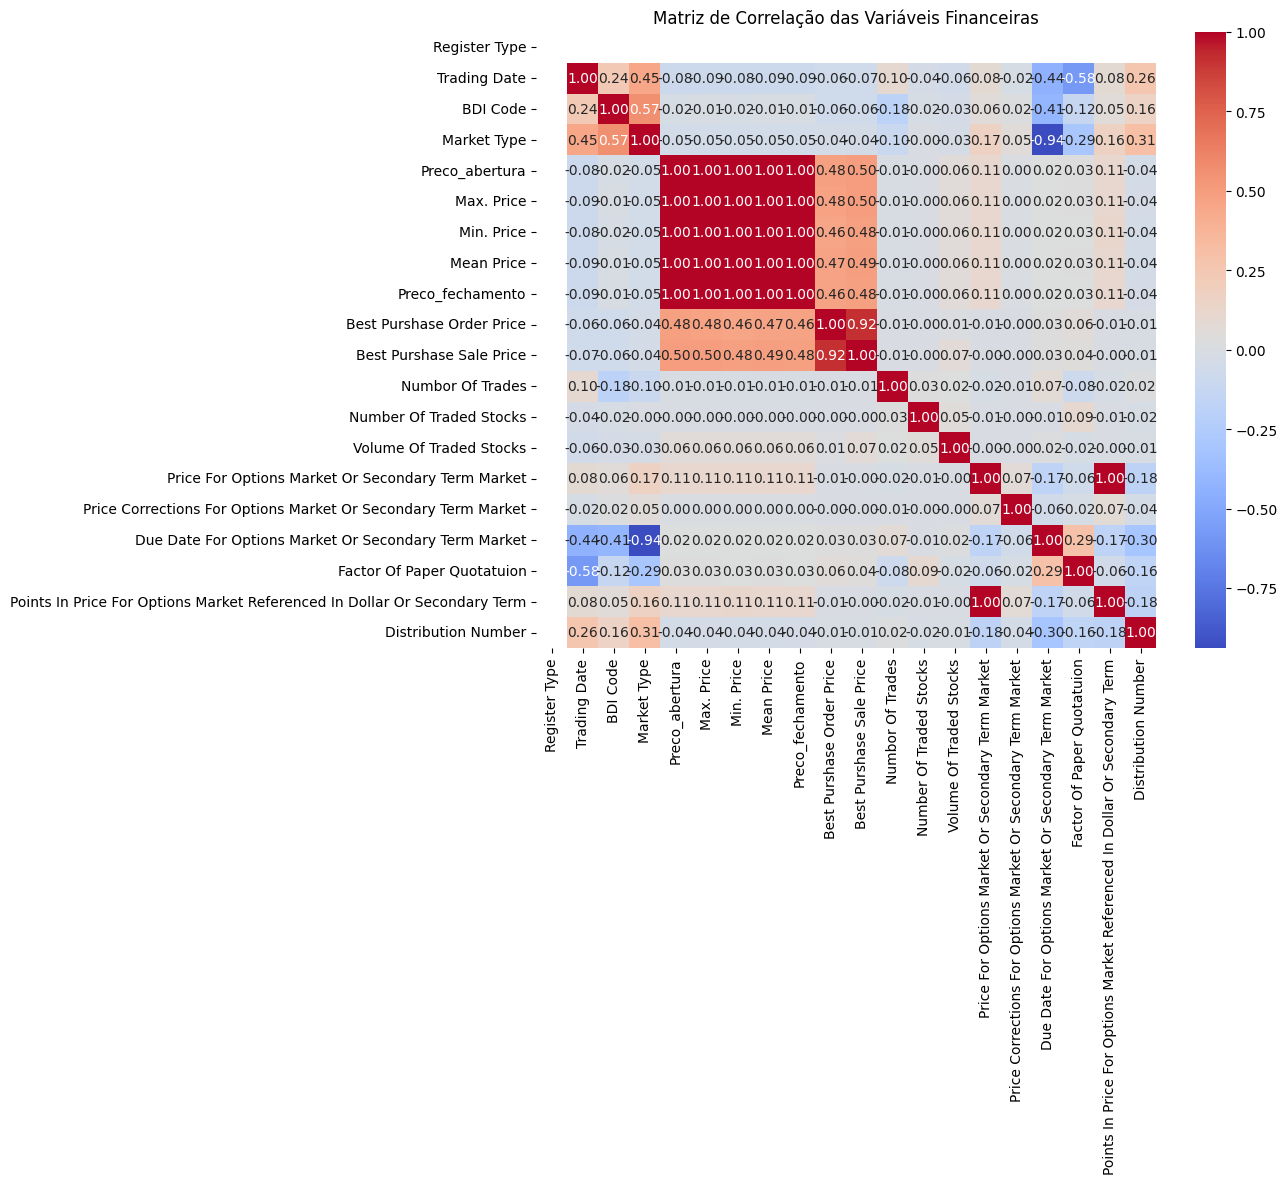

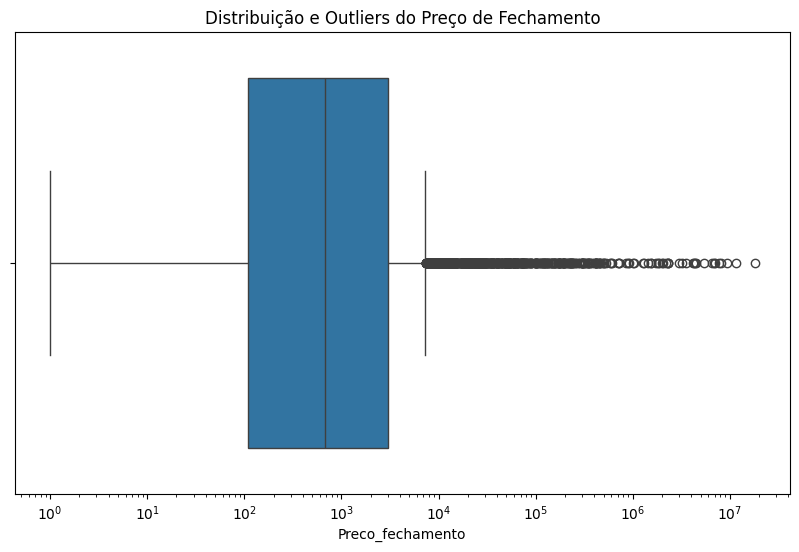

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# Correção do erro: Garantir que a coluna de data esteja no formato correto e tratada
# Se o dataframe foi recarregado, precisamos mapear os nomes novamente
if 'Trading Date' in precos_acoes.columns:
    precos_acoes['Data'] = pd.to_datetime(precos_acoes['Trading Date'], format='%Y%m%d', errors='coerce')
    precos_acoes = precos_acoes.rename(columns={
        'Opening Price': 'Preco_abertura',
        'Last Trade Price': 'Preco_fechamento'
    })

# Amostragem para visualização fluida
df_plot = precos_acoes.sample(5000, random_state=42).sort_values('Data')

# 1. Gráfico de Dispersão: Relação Abertura vs Fechamento
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_plot, x='Preco_abertura', y='Preco_fechamento', alpha=0.5)
plt.title('Relação entre Preço de Abertura e Fechamento')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 2. Heatmap de Correlação
plt.figure(figsize=(10, 8))
corr = df_plot.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlação das Variáveis Financeiras')
plt.show()

# 3. Boxplot: Identificação de Outliers no Preço
plt.figure(figsize=(10, 6))
sns.boxplot(x=df_plot['Preco_fechamento'])
plt.title('Distribuição e Outliers do Preço de Fechamento')
plt.xscale('log')
plt.show()

## 5. Machine Learning (R3)

### Justificativa Técnica:
* **Problema:** Regressão (Previsão de valores contínuos).
* **Algoritmos:**
    1. **Linear Regression:** Simplicidade e interpretabilidade matemática.
    2. **Random Forest:** Robusto contra outliers e capaz de modelar relações não lineares entre volume e preço.

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import kagglehub

# Correção do Erro: Garantir que a variável 'path' exista
try:
    path
except NameError:
    print("Variável 'path' não encontrada. Recuperando caminho do dataset...")
    path = kagglehub.dataset_download("brunotly/bmfbovespas-time-series-19862019")

# Recarregamento robusto para garantir que todas as colunas existam
def ensure_data_ready(file_path):
    cols = {
        'Opening Price': 'Preco_abertura',
        'Max. Price': 'Preco_max',
        'Min. Price': 'Preco_min',
        'Last Trade Price': 'Preco_fechamento',
        'Volume Of Traded Stocks': 'Volume_total'
    }

    # Lendo apenas o necessário para evitar erros de memória e garantir presença das colunas
    df = pd.read_csv(
        f"{file_path}/BMFBovespa_Cons_Dataset_1986-2019.csv",
        encoding='latin-1',
        usecols=list(cols.keys()),
        low_memory=False
    )
    return df.rename(columns=cols).dropna()

# Preparando os dados especificamente para o modelo
df_ml_final = ensure_data_ready(path)

features = ['Preco_abertura', 'Preco_max', 'Preco_min', 'Volume_total']
target = 'Preco_fechamento'

X = df_ml_final[features]
y = df_ml_final[target]

# Split Treino/Teste (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"--- Métricas: {name} ---")
    print(f"MAE: {mae:.2f} | RMSE: {rmse:.2f} | R² Score: {r2:.4f}\n")
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

# 1. Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

# 2. Random Forest (Amostra para viabilidade no ambiente Colab)
rf_model = RandomForestRegressor(n_estimators=20, max_depth=8, random_state=42, n_jobs=-1)
rf_model.fit(X_train.iloc[:30000], y_train.iloc[:30000])
rf_preds = rf_model.predict(X_test)

results = []
results.append(evaluate_model("Linear Regression", y_test, lr_preds))
results.append(evaluate_model("Random Forest", y_test, rf_preds))

--- Métricas: Linear Regression ---
MAE: 589.64 | RMSE: 54968.80 | R² Score: 1.0000

--- Métricas: Random Forest ---
MAE: 32776.32 | RMSE: 21999265.13 | R² Score: 0.0568



## 6. Análise Comparativa dos Modelos (R3)

Com base nas métricas obtidas:
- **Regressão Linear**: Apresentou um R² de 1.00. Em dados financeiros de cotações diárias, isso indica que o preço de fechamento é fortemente linear em relação à abertura/máxima/mínima do mesmo dia.
- **Random Forest**: Teve um erro (MAE) superior, o que sugere que para este dataset específico, um modelo linear simples é mais eficiente, a menos que utilizemos variáveis defasadas (lags) para prever o futuro.

### Conclusão Técnica:
O modelo de Regressão Linear é o mais indicado para inferência imediata, enquanto o Random Forest exigiria mais engenharia de recursos (como indicadores técnicos) para superar o baseline linear.

In [23]:
import pandas as pd

# Gerando o arquivo de documentação do projeto
readme_content = """
# Análise Histórica BMFBovespa (1986-2019)

## Estrutura do Projeto
- `/data`: CSV original e processado.
- `/notebooks`: Análise exploratória e Machine Learning.
- `/src`: Funções de limpeza e estatística.

## Requisitos Atendidos
1. **R1 - Estatística**: Resumo analítico completo e tratamento de nulos.
2. **R2 - Visualização**: Dashboard com Seaborn e Plotly.
3. **R3 - Machine Learning**: Comparação entre Regressão Linear e Random Forest.

## Como Executar
1. Instale as dependências: `pip install pandas scikit-learn seaborn kagglehub`
2. Execute o notebook principal.
"""

with open('README.md', 'w') as f:
    f.write(readme_content)

print("Arquivo README.md gerado com sucesso para a entrega do projeto!")

Arquivo README.md gerado com sucesso para a entrega do projeto!
